In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("borhanitrash/alzheimer-mri-disease-classification-dataset")

print("Dataset downloaded to:", path)
print("Folders inside:", os.listdir(path))

100%|██████████| 26.0M/26.0M [00:00<00:00, 39.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1
Folders inside: ['Alzheimer MRI Disease Classification Dataset']


In [ ]:
import os

base_dir = "/root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1/Alzheimer MRI Disease Classification Dataset"

print("Contents of base dir:", os.listdir(base_dir))

for item in os.listdir(base_dir):
    item_path = os.path.join(base_dir, item)
    if os.path.isdir(item_path):
        print(f"{item}/ ->", os.listdir(item_path)[:5])  # show first 5 items

Contents of base dir: ['README.md', 'Data']
Data/ -> ['test-00000-of-00001-44110b9df98c5585.parquet', 'train-00000-of-00001-c08a401c53fe5312.parquet']


In [ ]:
import os
import pandas as pd

base_dir = "/root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1/Alzheimer MRI Disease Classification Dataset/Data"

train_path = os.path.join(base_dir, "train-00000-of-00001-c08a401c53fe5312.parquet")
test_path = os.path.join(base_dir, "test-00000-of-00001-44110b9df98c5585.parquet")

# Load parquet into DataFrame
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Train columns:", train_df.columns)
print("Train shape:", train_df.shape)
print(train_df.head())

Train columns: Index(['image', 'label'], dtype='object')
Train shape: (5120, 2)
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2


In [ ]:
!pip install torch torchvision torchsummary pandas pyarrow scikit-learn seaborn matplotlib tqdm lime scikit-image opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=044934cc0593474a4b07ec50f22930cb98c4631472760603d549f8f1bf4c0ed4
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Using device: cuda
   Federated Learning for Alzheimer MRI Classification (EfficientNet-B4)   

Step 1: Preparing federated data from Parquet...
Loading and processing training data from: /root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1/Alzheimer MRI Disease Classification Dataset/Data/train-00000-of-00001-c08a401c53fe5312.parquet
Loading and processing test data from: /root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1/Alzheimer MRI Disease Classification Dataset/Data/test-00000-of-00001-44110b9df98c5585.parquet
Splitting training data: 4352 train, 768 validation
Client 1 training dataset size: 1088
Client 2 training dataset size: 1088
Client 3 training dataset size: 1088
Client 4 training dataset size: 1088

Dataset split across 4 clients. Classes: ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']

Step 2: Training federated model...
Downloading: "https://do

100%|██████████| 74.5M/74.5M [00:00<00:00, 181MB/s]


Model Parameter Count:
Total parameters: 18,473,292
Trainable parameters: 18,473,292

  EfficientNet-B4 Model Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 48, 112, 112]           1,296
       BatchNorm2d-2         [-1, 48, 112, 112]              96
              SiLU-3         [-1, 48, 112, 112]               0
            Conv2d-4         [-1, 48, 112, 112]             432
       BatchNorm2d-5         [-1, 48, 112, 112]              96
              SiLU-6         [-1, 48, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 48, 1, 1]               0
            Conv2d-8             [-1, 12, 1, 1]             588
              SiLU-9             [-1, 12, 1, 1]               0
           Conv2d-10             [-1, 48, 1, 1]             624
          Sigmoid-11             [-1, 48, 1, 1]               0
SqueezeExcitation-12         [-1, 48, 112, 112]  

Round 1 Training: 100%|██████████| 4/4 [08:16<00:00, 124.18s/it, Client=4, Loss=1.4936, Acc=47.15%]


Global Model Validation: Loss = 1.0124, Accuracy = 56.25%
✅ New best model saved! Validation Accuracy: 56.25%

[ Communication Round 2/15 | LR: 0.001 ]


...

Global Model Validation: Loss = 0.0940, Accuracy = 99.74%
✅ New best model saved! Validation Accuracy: 99.74%

[ Communication Round 14/15 | LR: 0.001 ]


Round 14 Training: 100%|██████████| 4/4 [08:19<00:00, 124.97s/it, Client=4, Loss=0.3752, Acc=99.24%]


Global Model Validation: Loss = 0.1071, Accuracy = 99.35%

[ Communication Round 15/15 | LR: 0.001 ]


Round 15 Training: 100%|██████████| 4/4 [08:19<00:00, 124.94s/it, Client=4, Loss=0.3806, Acc=99.12%]


Global Model Validation: Loss = 0.1081, Accuracy = 99.48%
📉 Learning rate decayed to 0.0001

Step 3: Plotting training history...


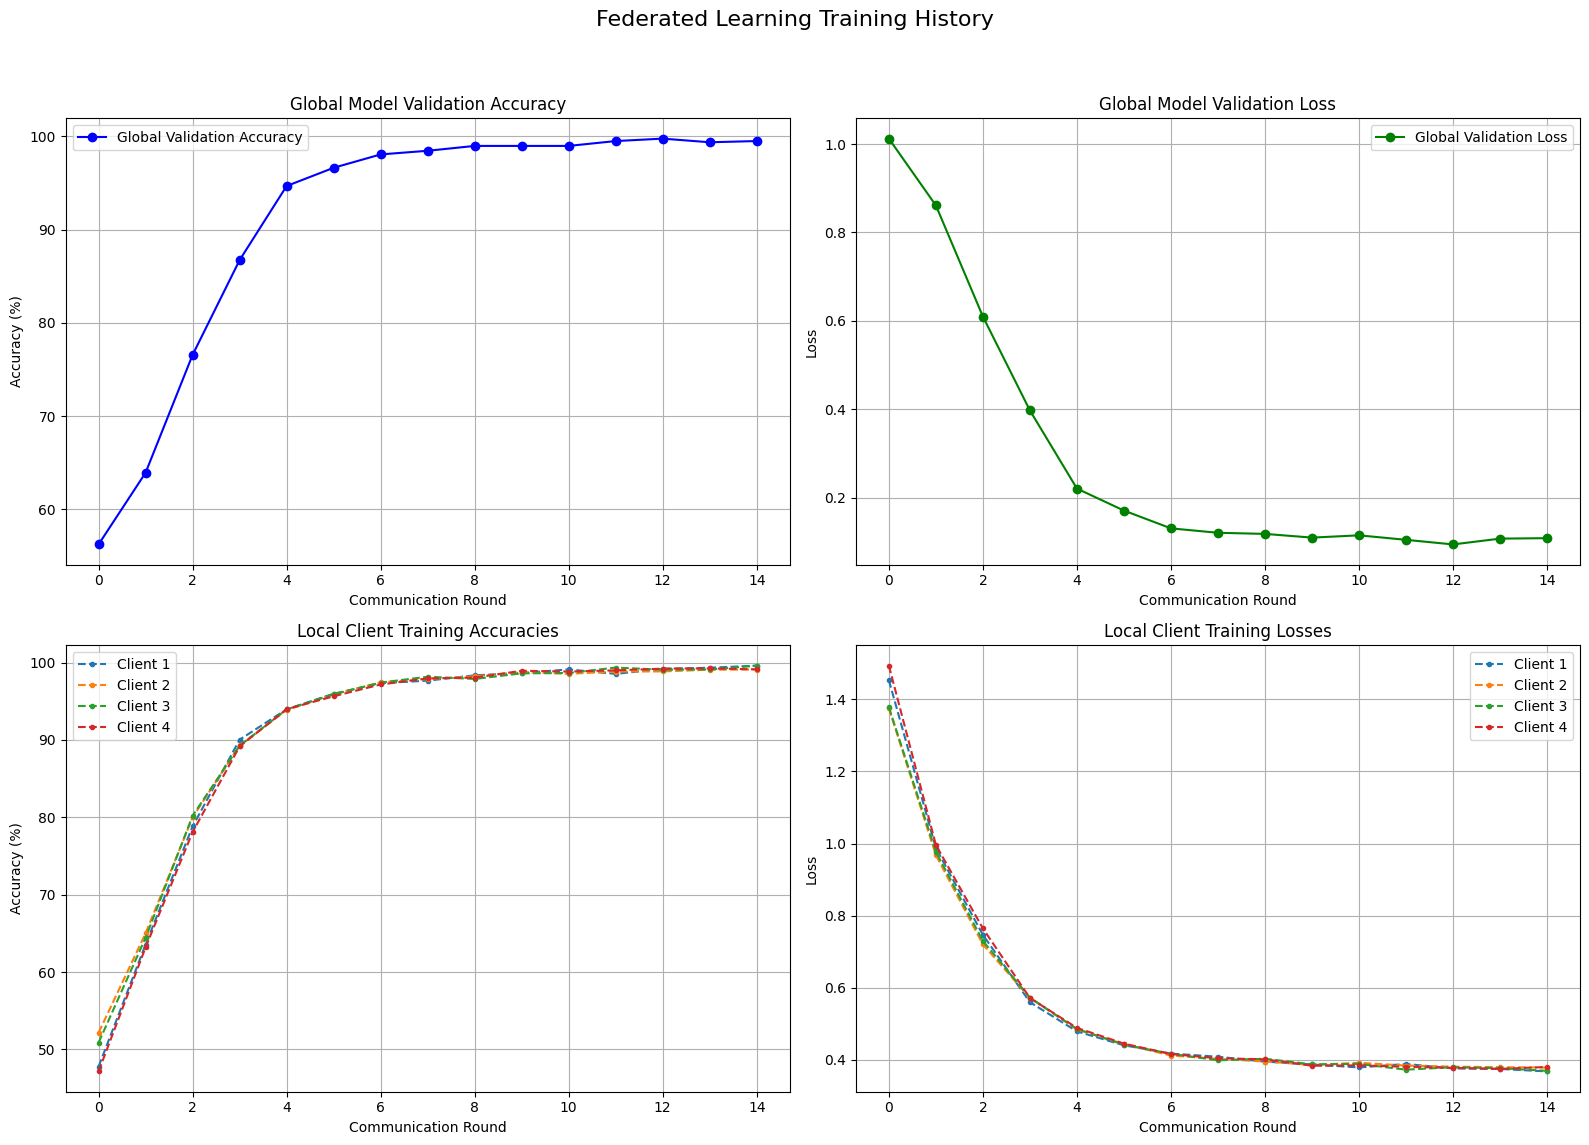


Step 4: Evaluating final model on the test set...

========================= FINAL TEST RESULTS =========================
  Test Accuracy:   99.2969%
  ROC AUC (Macro): 0.9992

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented     1.0000    0.9709    0.9853       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9922    0.9968    0.9945       634
Very Mild Demented     0.9913    0.9956    0.9935       459

          accuracy                         0.9930      1280
         macro avg     0.9959    0.9909    0.9933      1280
      weighted avg     0.9930    0.9930    0.9930      1280


Step 5: Plotting evaluation metrics...


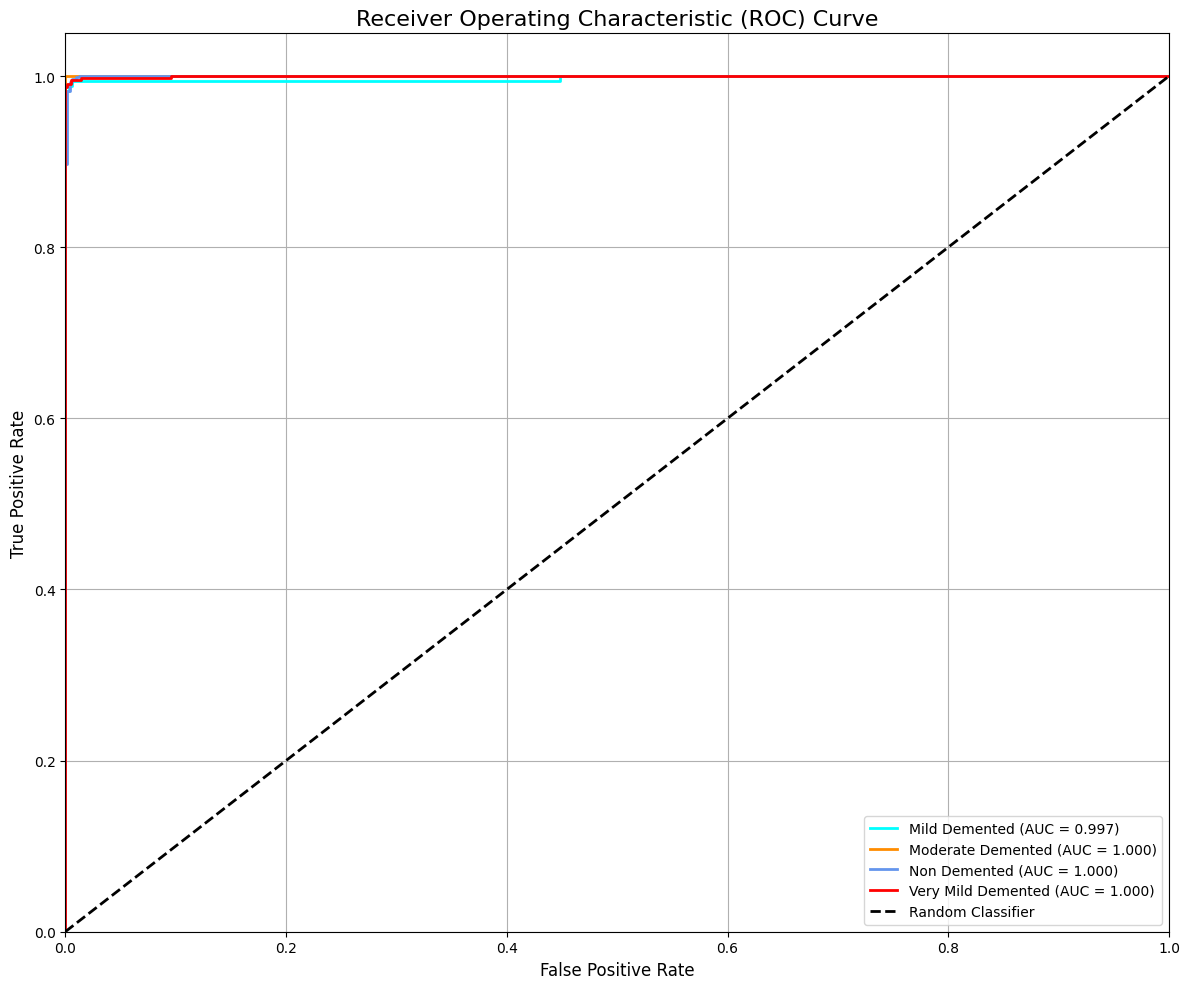

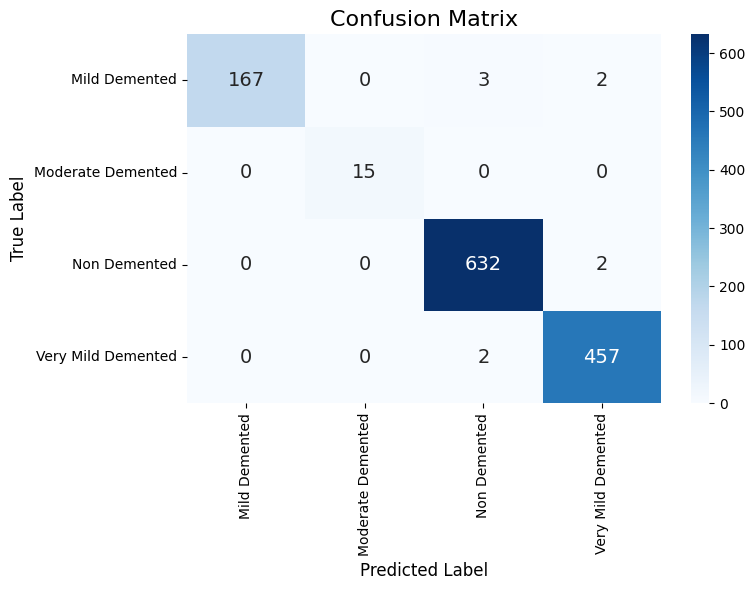


Step 6: Generating XAI visualizations...

--- XAI: Generating Saliency Map Explanations ---
  Saliency Map for sample 1/5...


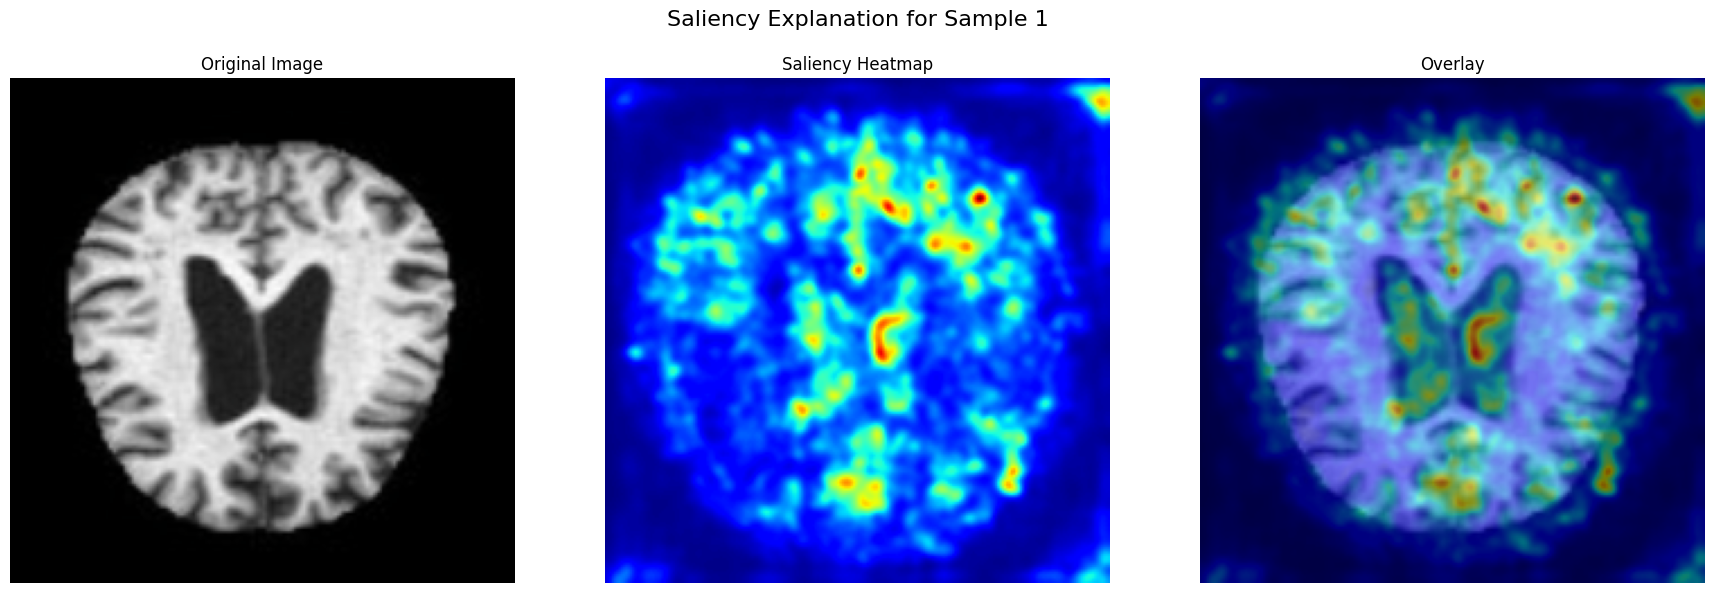

  Saliency Map for sample 2/5...


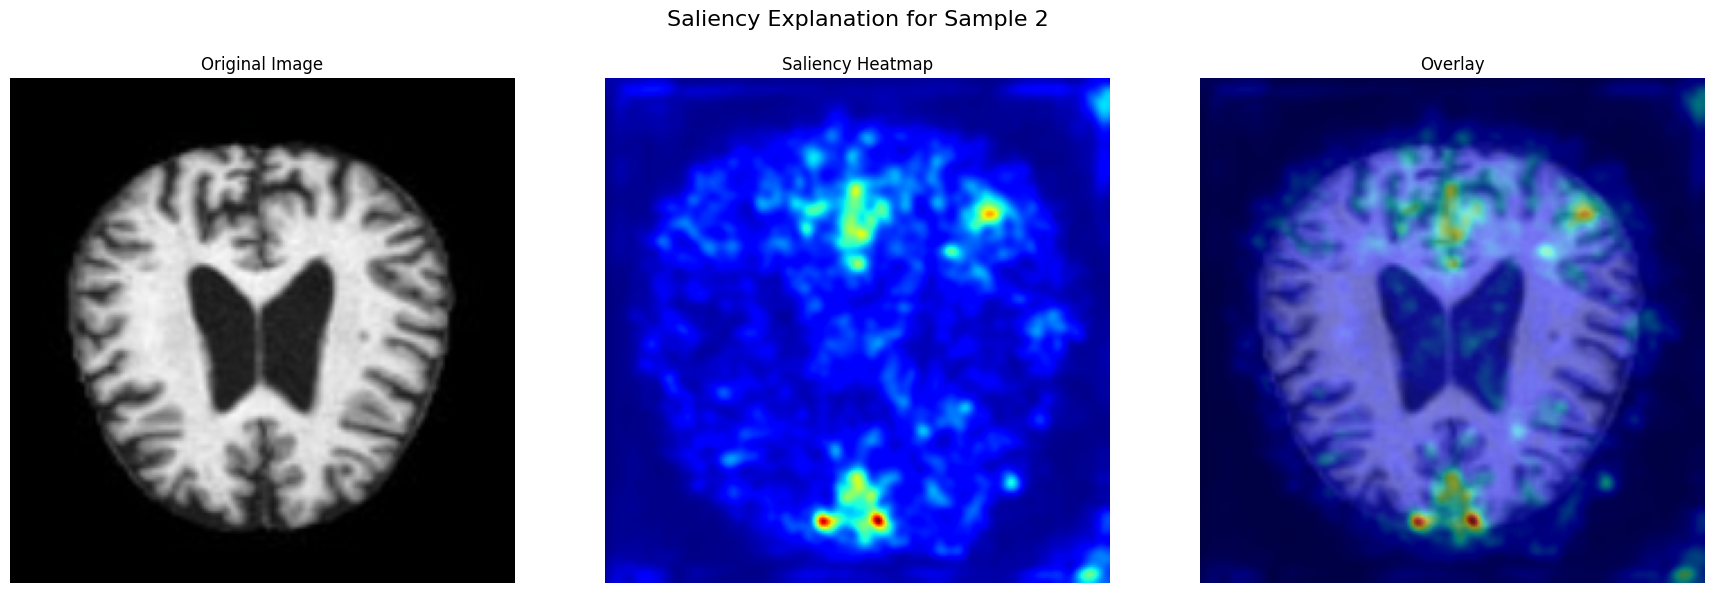

  Saliency Map for sample 3/5...


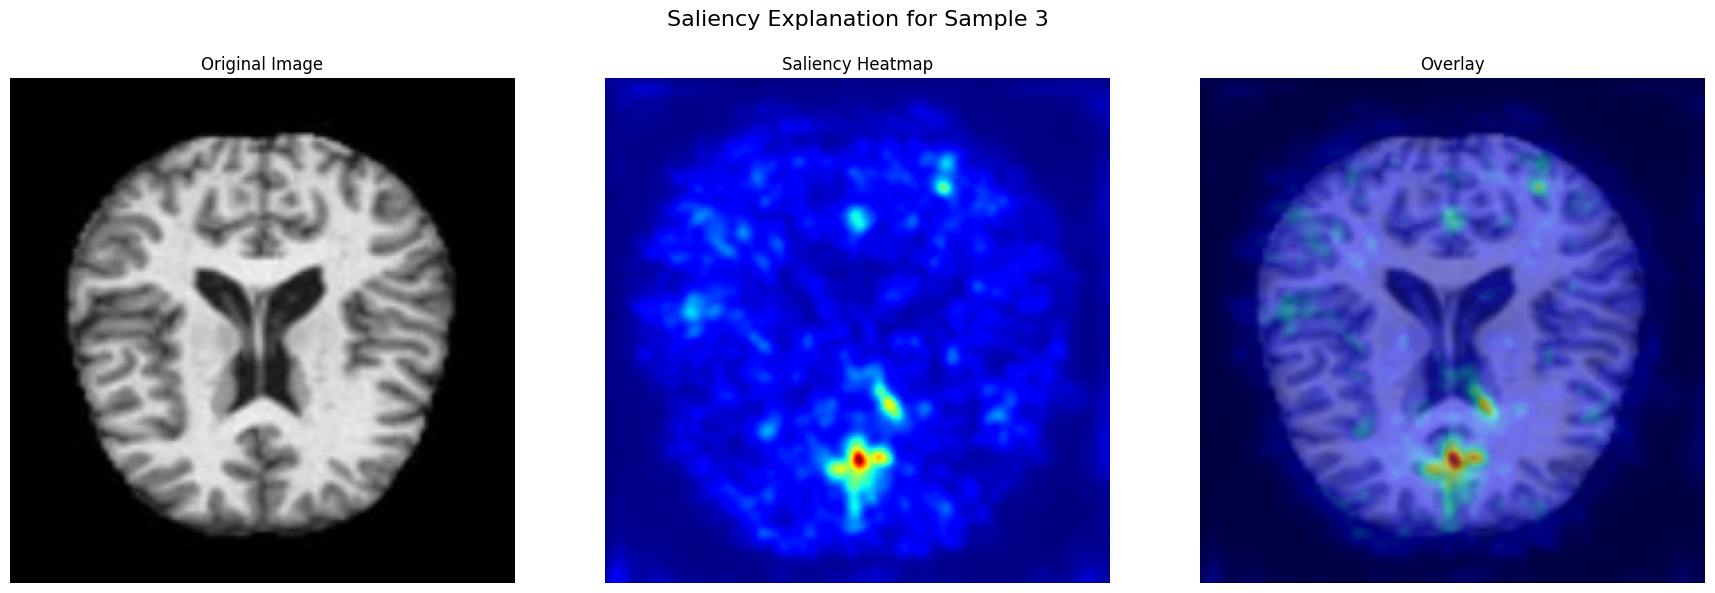

  Saliency Map for sample 4/5...


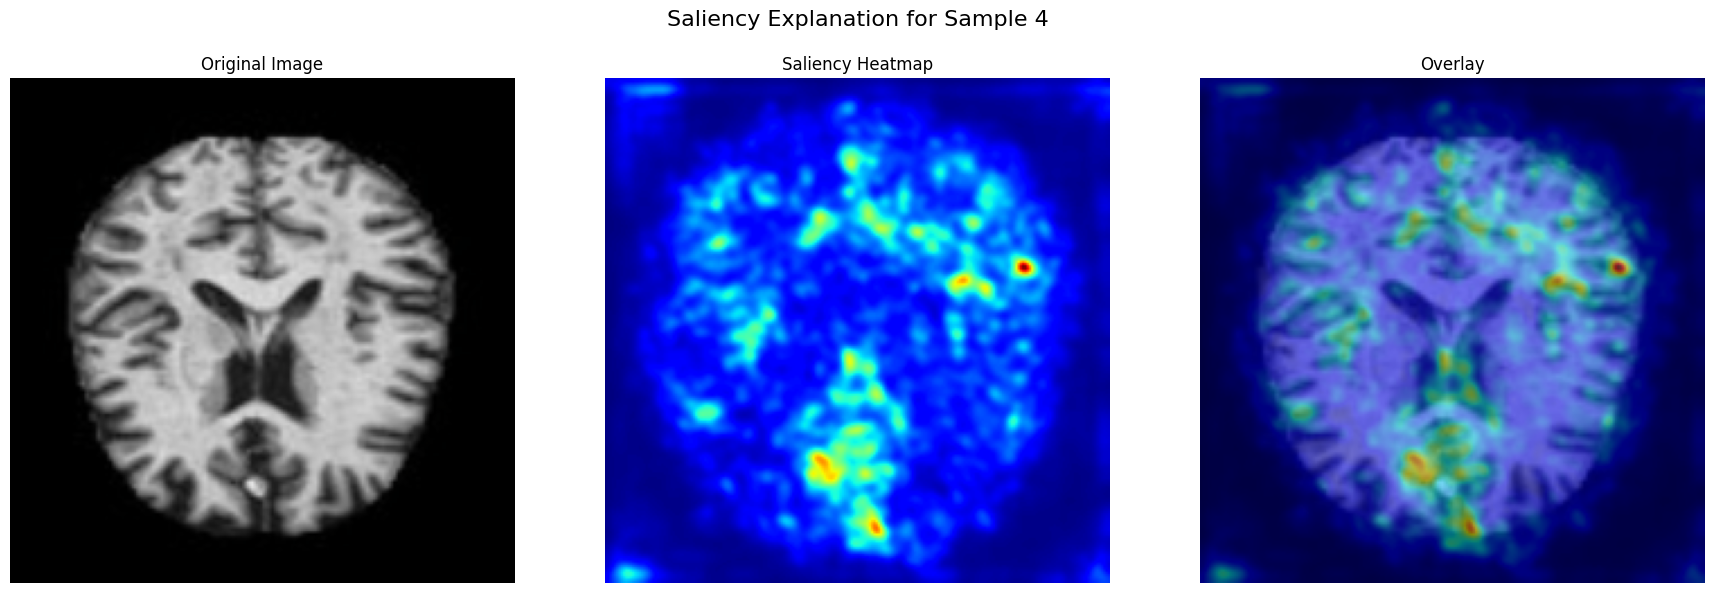

  Saliency Map for sample 5/5...


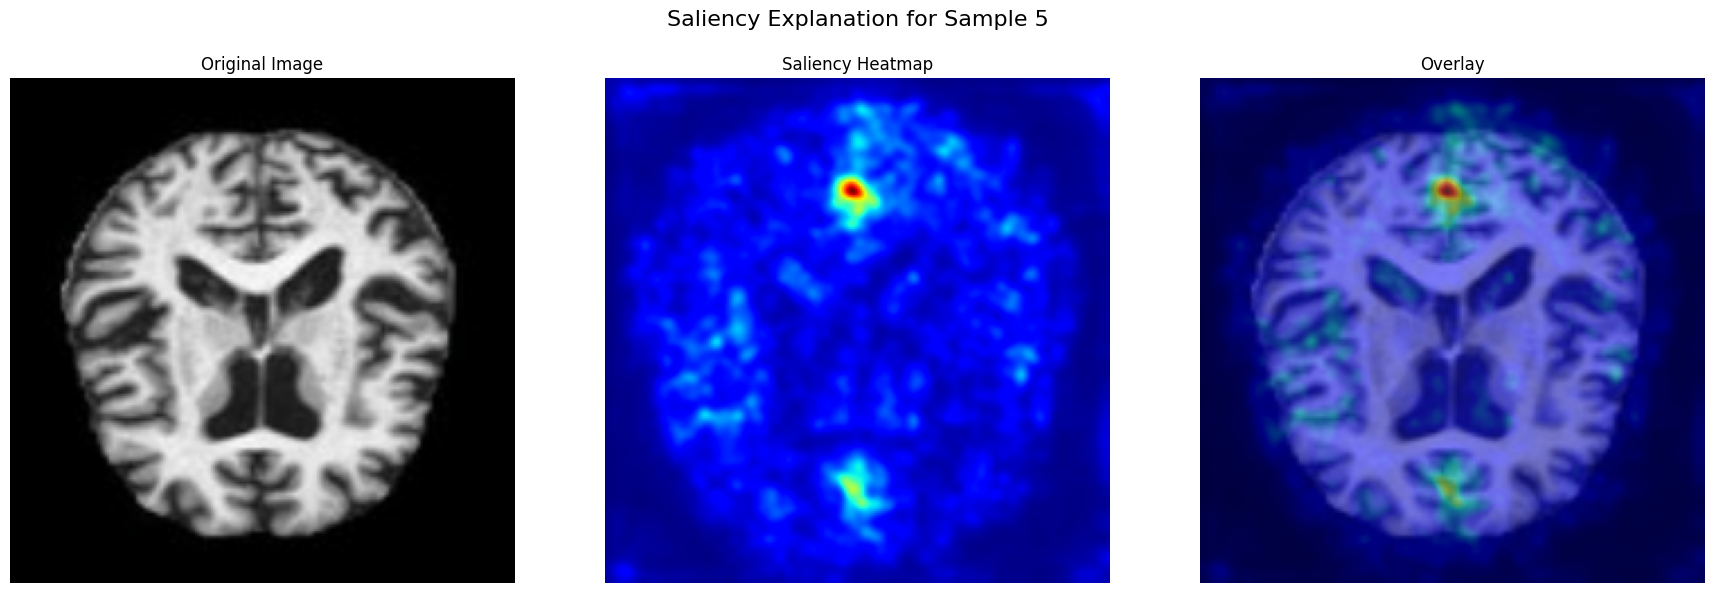


--- XAI: Generating LIME Explanations ---
  LIME explanation for sample 1/5...


  0%|          | 0/1000 [00:00<?, ?it/s]

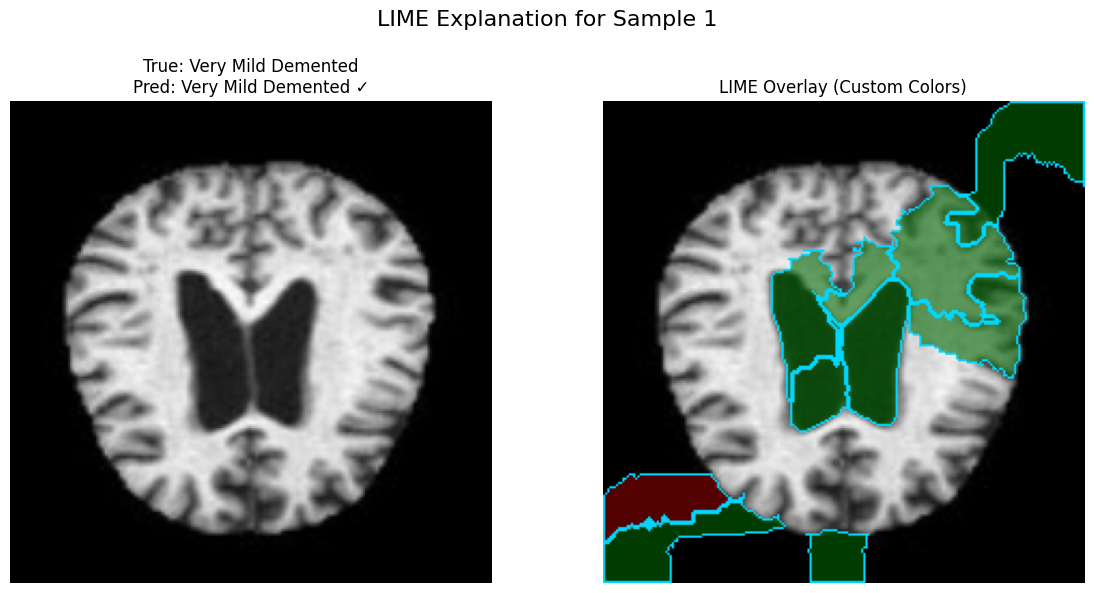

  LIME explanation for sample 2/5...


  0%|          | 0/1000 [00:00<?, ?it/s]

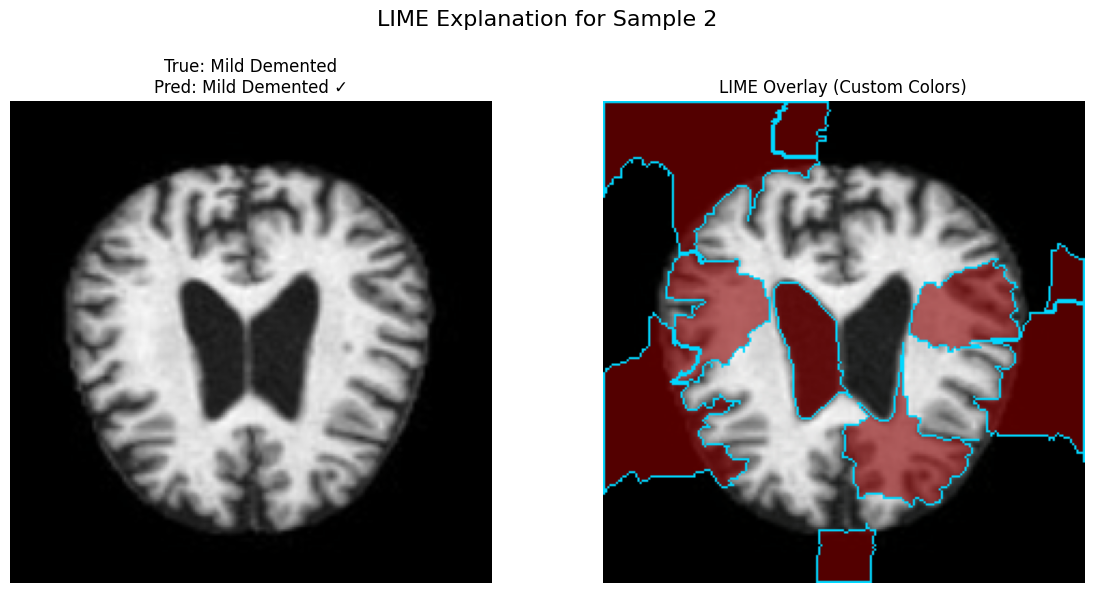

  LIME explanation for sample 3/5...


  0%|          | 0/1000 [00:00<?, ?it/s]

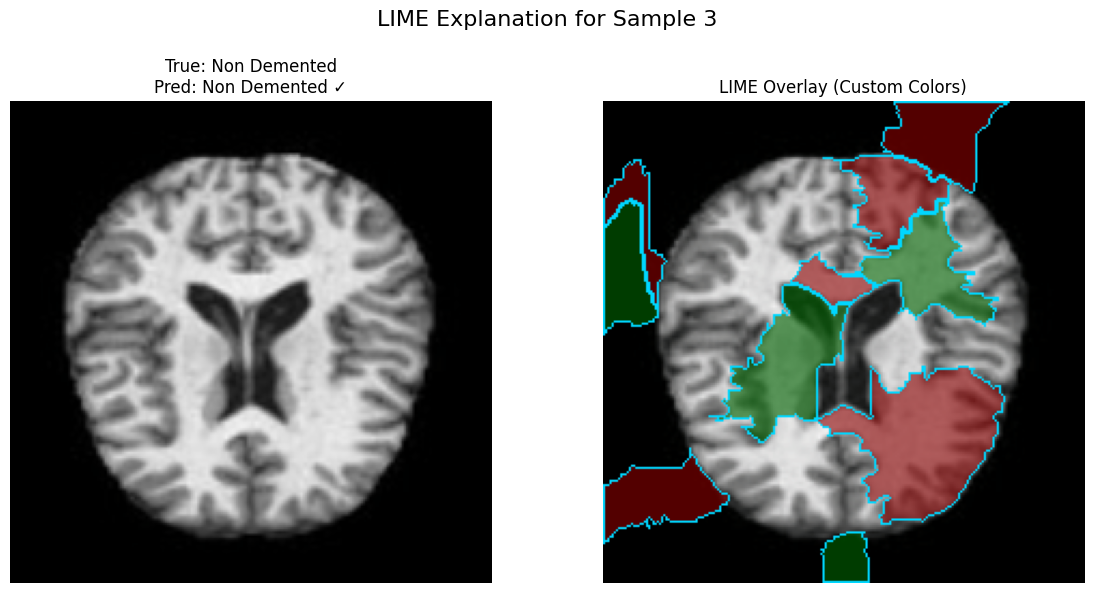

  LIME explanation for sample 4/5...


  0%|          | 0/1000 [00:00<?, ?it/s]

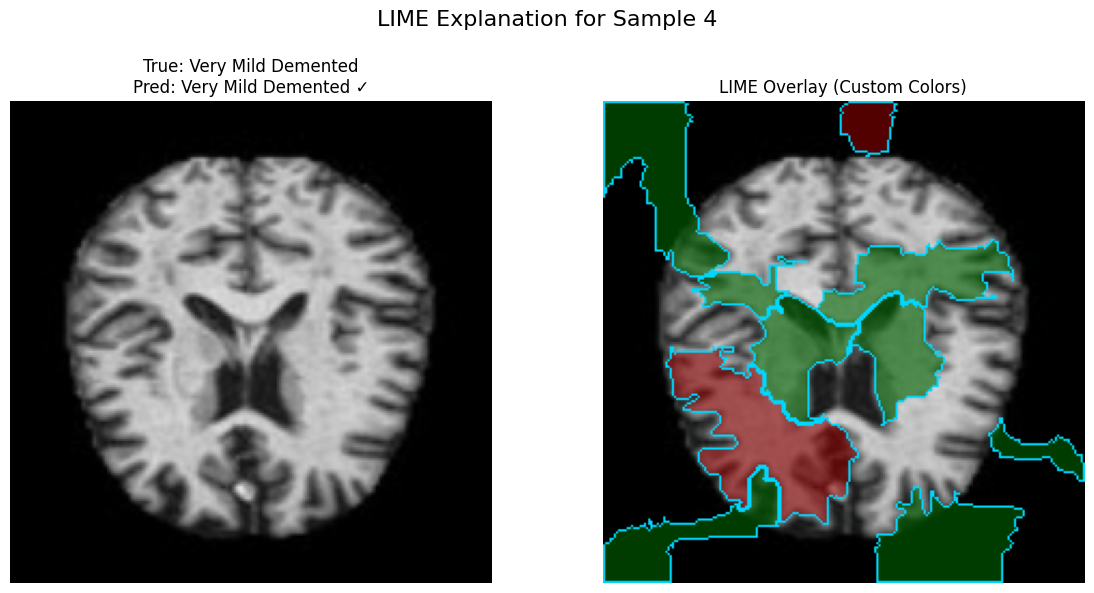

  LIME explanation for sample 5/5...


  0%|          | 0/1000 [00:00<?, ?it/s]

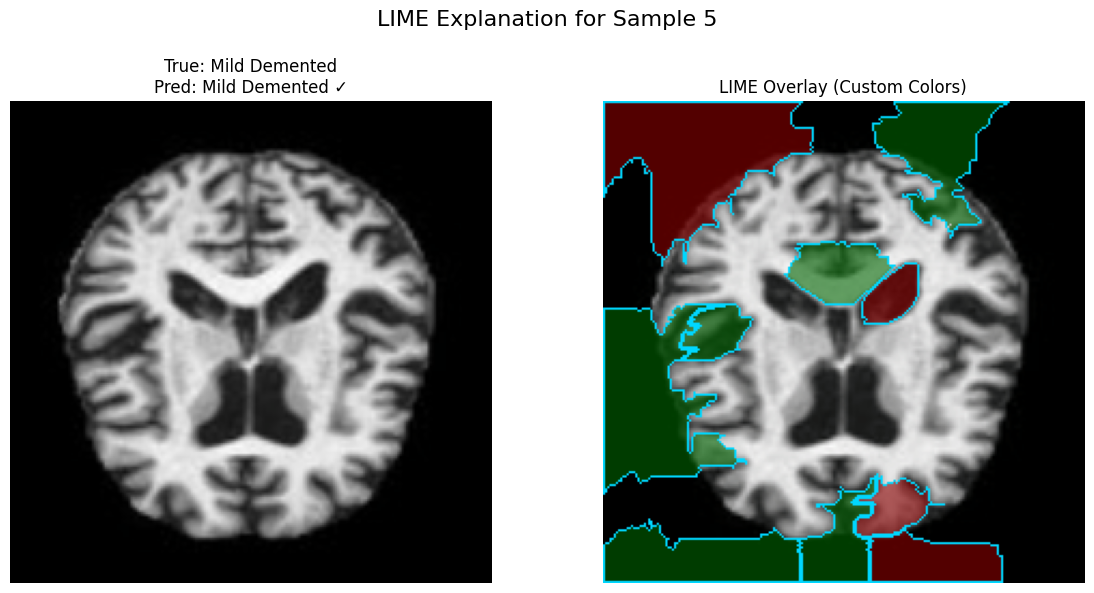


🎉 Training and evaluation completed! Final model saved with test accuracy: 99.2969%


In [ ]:
# ===================================================================
#                           1. IMPORTS
# ===================================================================
import os
import copy
import warnings
from itertools import cycle
import io

# --- PyTorch & Torchvision ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchsummary import summary

# --- Data Science & Plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image
from tqdm import tqdm

# --- Explainable AI (XAI) ---
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
from scipy.ndimage import gaussian_filter
import cv2  # OpenCV for drawing contours

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# ===================================================================
#                      2. DEVICE CONFIGURATION
# ===================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ===================================================================
#                3. MODEL & FEDERATED FRAMEWORK CLASSES
# ===================================================================

class EfficientNet_FedNet(nn.Module):
    """
    Federated Learning model using a pre-trained EfficientNet-B4.
    This model is more advanced and often yields higher accuracy than ResNet50.
    """
    def __init__(self, num_classes=4):
        super(EfficientNet_FedNet, self).__init__()
        # Load a pre-trained EfficientNet-B4 model with the latest recommended weights
        self.efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)

        # Replace the final classifier layer with a new one tailored to our specific task
        num_ftrs = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        # Initialize the weights of the new layers
        for m in self.efficientnet.classifier:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.efficientnet(x)


class FederatedClient:
    """Simulates a client in the federated learning network."""
    def __init__(self, model, client_data, client_id, learning_rate):
        self.model = model
        self.client_data = client_data
        self.client_id = client_id
        # Use AdamW optimizer, which is excellent for training modern neural networks
        self.optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    def set_learning_rate(self, lr):
        """Allows the server to update the client's learning rate."""
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def local_train(self, epochs=5):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        for epoch in range(epochs):
            for data, target in self.client_data:
                data, target = data.to(device), target.to(device)
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                total_loss += loss.item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
                total += target.size(0)
        return total_loss / (len(self.client_data) * epochs), 100. * correct / total

    def get_model_params(self):
        return copy.deepcopy(self.model.state_dict())


class FederatedServer:
    """Simulates the central server that aggregates models."""
    def __init__(self, global_model, num_clients):
        self.global_model = global_model
        self.num_clients = num_clients

    def aggregate_models(self, client_models):
        global_dict = self.global_model.state_dict()
        for key in global_dict.keys():
            client_tensors = [model_params[key].float().to(device) for model_params in client_models]
            global_dict[key] = torch.stack(client_tensors, 0).mean(0)
        self.global_model.load_state_dict(global_dict)


# ===================================================================
#                   4. EXPLAINABLE AI (XAI) CLASSES
# ===================================================================

class SaliencyMap:
    """Generates attribution maps using the gradient of the output wrt the input."""
    def __call__(self, model, input_tensor):
        try:
            model.eval()
            input_tensor.requires_grad = True
            output = model(input_tensor)
            pred_class = output.argmax(dim=1)
            model.zero_grad()
            output[0, pred_class].backward()
            gradients = input_tensor.grad.data.abs().mean(dim=1).squeeze()
            heatmap = F.interpolate(gradients.unsqueeze(0).unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False).squeeze().cpu().numpy()
            return heatmap
        except Exception as e:
            print(f"Saliency map generation failed: {e}")
            return np.zeros((224, 224))


class LimeExplainer:
    """A wrapper for LIME functionality to explain model predictions."""
    def __init__(self, model):
        self.model = model
        self.explainer = lime_image.LimeImageExplainer()
        self.normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    def _predict_fn_lime(self, images_np):
        """Prediction function required by LIME."""
        self.model.eval()
        imgs_torch = torch.tensor(images_np.transpose(0, 3, 1, 2), dtype=torch.float32).to(device)
        imgs_torch_norm = self.normalize(imgs_torch)
        with torch.no_grad():
            outputs = self.model(imgs_torch_norm)
        return F.softmax(outputs, dim=1).cpu().numpy()

    def explain_instance(self, image_np_uint8):
        """Generates a LIME explanation object for a single image."""
        return self.explainer.explain_instance(
            image=image_np_uint8,
            classifier_fn=self._predict_fn_lime,
            top_labels=5,
            hide_color=0,
            num_samples=1000,
            random_seed=42
        )


# ===================================================================
#                   5. HELPER & UTILITY FUNCTIONS
# ===================================================================

class ParquetDataset(Dataset):
    """
    Custom PyTorch Dataset for loading image data from a Parquet file.
    This version assumes the 'label' column contains integers.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get image bytes and the integer label from the dataframe
        image_bytes = self.dataframe.iloc[idx]['image']['bytes']
        label = self.dataframe.iloc[idx]['label']

        # Convert bytes to a PIL Image and ensure it's in RGB format
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

        # Apply transformations if they exist
        if self.transform:
            image = self.transform(image)

        # The label is already an integer, so no mapping is needed here
        return image, label


def get_data_transforms():
    """
    Defines enhanced transformations for training and standard transformations
    for validation/testing to maximize model performance.
    """
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_transform, val_test_transform


def prepare_federated_data_parquet(train_path, test_path, batch_size=32, num_clients=4):
    """
    Loads data from Parquet files, performs a train/val split, and distributes
    the training data among federated clients.
    """
    train_transform, val_test_transform = get_data_transforms()

    # *** FIX: Define the mapping from integer labels to string class names ***
    INT_TO_CLASS_NAME = {
        0: 'Mild Demented',
        1: 'Moderate Demented',
        2: 'Non Demented',
        3: 'Very Mild Demented'
    }

    print(f"Loading and processing training data from: {train_path}")
    train_df = pd.read_parquet(train_path)
    print(f"Loading and processing test data from: {test_path}")
    test_df = pd.read_parquet(test_path)

    full_train_dataset = ParquetDataset(train_df, transform=train_transform)
    test_dataset = ParquetDataset(test_df, transform=val_test_transform)

    # *** FIX: Generate the list of class names in the correct order for reporting ***
    sorted_unique_labels = sorted(train_df['label'].unique())
    class_names = [INT_TO_CLASS_NAME[label] for label in sorted_unique_labels]

    dataset_size = len(full_train_dataset)
    val_size = int(0.15 * dataset_size) # Increased validation size for more reliable metrics
    train_size = dataset_size - val_size
    print(f"Splitting training data: {train_size} train, {val_size} validation")
    train_dataset, val_dataset = random_split(
        full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    num_train_samples = len(train_dataset)
    client_data_size = num_train_samples // num_clients
    client_indices_split = [client_data_size] * (num_clients - 1)
    client_indices_split.append(num_train_samples - sum(client_indices_split))
    client_datasets = random_split(
        train_dataset, client_indices_split, generator=torch.Generator().manual_seed(42)
    )

    for i, ds in enumerate(client_datasets):
        print(f"Client {i+1} training dataset size: {len(ds)}")

    client_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True) for ds in client_datasets]
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return client_loaders, val_loader, test_loader, class_names


def count_parameters(model):
    """Counts the total and trainable parameters of a model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}\nTrainable parameters: {trainable_params:,}")


def validate_model(model, val_loader, criterion):
    """Evaluates the model on the validation dataset."""
    model.eval(); val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    return val_loss / len(val_loader), 100. * correct / total


def test_model(model, test_loader, class_names):
    """Evaluates the final model on the hold-out test set."""
    model.eval(); y_true, y_pred, y_scores = [], [], []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            y_true.extend(target.cpu().numpy()); y_pred.extend(output.argmax(dim=1).cpu().numpy()); y_scores.extend(F.softmax(output, dim=1).cpu().numpy())
    y_true, y_pred, y_scores = np.array(y_true), np.array(y_pred), np.array(y_scores)
    accuracy = np.mean(y_true == y_pred) * 100
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    roc_auc = roc_auc_score(y_true, y_scores[:, 1]) if len(class_names) == 2 else roc_auc_score(y_true_bin, y_scores, average='macro')
    return accuracy, report, cm, roc_auc, y_true, y_pred, y_scores


# ===================================================================
#                   6. VISUALIZATION FUNCTIONS
# ===================================================================

def plot_training_history(history):
    """Plots the training and validation history."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Federated Learning Training History', fontsize=16)
    axes[0, 0].plot(history['val_acc'], 'b-o', label='Global Validation Accuracy'); axes[0, 0].set_title('Global Model Validation Accuracy'); axes[0, 0].set_xlabel('Communication Round'); axes[0, 0].set_ylabel('Accuracy (%)'); axes[0, 0].legend(); axes[0, 0].grid(True)
    axes[0, 1].plot(history['val_loss'], 'g-o', label='Global Validation Loss'); axes[0, 1].set_title('Global Model Validation Loss'); axes[0, 1].set_xlabel('Communication Round'); axes[0, 1].set_ylabel('Loss'); axes[0, 1].legend(); axes[0, 1].grid(True)
    for i, acc in enumerate(history['client_acc']): axes[1, 0].plot(acc, marker='.', linestyle='--', label=f'Client {i+1}')
    axes[1, 0].set_title('Local Client Training Accuracies'); axes[1, 0].set_xlabel('Communication Round'); axes[1, 0].set_ylabel('Accuracy (%)'); axes[1, 0].legend(); axes[1, 0].grid(True)
    for i, loss in enumerate(history['client_loss']): axes[1, 1].plot(loss, marker='.', linestyle='--', label=f'Client {i+1}')
    axes[1, 1].set_title('Local Client Training Losses'); axes[1, 1].set_xlabel('Communication Round'); axes[1, 1].set_ylabel('Loss'); axes[1, 1].legend(); axes[1, 1].grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.savefig('federated_training_history_alzheimer_efficientnet.png', dpi=300); plt.show()


def plot_confusion_matrix(cm, class_names):
    """Plots a heatmap of the confusion matrix."""
    plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
    plt.title('Confusion Matrix', fontsize=16); plt.ylabel('True Label', fontsize=12); plt.xlabel('Predicted Label', fontsize=12); plt.tight_layout(); plt.savefig('confusion_matrix_alzheimer_efficientnet.png', dpi=300); plt.show()


def plot_roc_curves(y_true, y_scores, class_names):
    """Plots the ROC curves. Handles both binary and multi-class cases."""
    if len(class_names) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6)); plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})'); plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    else:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names))); n_classes = len(class_names)
        fpr, tpr, roc_auc = dict(), dict(), dict()
        for i in range(n_classes): fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i]); roc_auc[i] = auc(fpr[i], tpr[i])
        plt.figure(figsize=(12, 10)); colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])
        for i, color in zip(range(n_classes), colors): plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12); plt.ylabel('True Positive Rate', fontsize=12); plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16); plt.legend(loc="lower right"); plt.grid(True); plt.tight_layout(); plt.savefig('roc_curves_alzheimer_efficientnet.png', dpi=300); plt.show()


def visualize_saliency_maps(model, test_loader, class_names, num_samples=5):
    """Visualizes Saliency Maps for a few sample images."""
    print("\n--- XAI: Generating Saliency Map Explanations ---")
    model.to(device).eval(); saliency_explainer = SaliencyMap()
    samples_collected = []; test_loader_iter = iter(test_loader)
    while len(samples_collected) < num_samples:
        try:
            data, _ = next(test_loader_iter)
            for i in range(len(data)):
                if len(samples_collected) < num_samples: samples_collected.append({'image': data[i]})
        except StopIteration: break
    denormalize = transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225])
    for idx, sample in enumerate(samples_collected):
        print(f"  Saliency Map for sample {idx+1}/{num_samples}...")
        input_tensor = sample['image']; img_denorm = denormalize(input_tensor); img_np = img_denorm.permute(1, 2, 0).cpu().numpy(); img_np = np.clip(img_np, 0, 1)
        saliency_mask = saliency_explainer(model, input_tensor.unsqueeze(0).to(device)); saliency_mask = gaussian_filter(saliency_mask, sigma=2)
        if saliency_mask.max() > saliency_mask.min(): saliency_mask = (saliency_mask - saliency_mask.min()) / (saliency_mask.max() - saliency_mask.min())
        heatmap = plt.cm.jet(saliency_mask)[:, :, :3]; overlay = Image.blend(Image.fromarray((img_np * 255).astype(np.uint8)), Image.fromarray((heatmap * 255).astype(np.uint8)), alpha=0.5)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6)); fig.suptitle(f'Saliency Explanation for Sample {idx+1}', fontsize=16)
        axes[0].imshow(img_np); axes[0].set_title('Original Image'); axes[0].axis('off'); axes[1].imshow(saliency_mask, cmap='jet'); axes[1].set_title('Saliency Heatmap'); axes[1].axis('off'); axes[2].imshow(overlay); axes[2].set_title('Overlay'); axes[2].axis('off')
        plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.savefig(f'saliency_explanation_alzheimer_efficientnet_{idx}.png', dpi=150); plt.show()


def visualize_lime_explanations(model, test_loader, class_names, num_samples=5, num_lime_features=10):
    """Visualizes LIME explanations with custom colors and borders."""
    print("\n--- XAI: Generating LIME Explanations ---")
    model.to(device).eval(); lime_explainer = LimeExplainer(model)
    samples_collected = []; test_loader_iter = iter(test_loader)
    while len(samples_collected) < num_samples:
        try:
            data, target = next(test_loader_iter); output = model(data.to(device)); pred = output.argmax(dim=1)
            for i in range(len(data)):
                if len(samples_collected) < num_samples: samples_collected.append({'image': data[i], 'true_label': target[i].item(), 'pred_label': pred[i].cpu().item()})
        except StopIteration: break
    denormalize = transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225])
    dark_green_rgb = np.array([0, 100, 0], dtype=np.float32); dark_red_rgb = np.array([139, 0, 0], dtype=np.float32); golden_color_bgr = (0, 215, 255); alpha = 0.6
    for idx, sample in enumerate(samples_collected):
        print(f"  LIME explanation for sample {idx+1}/{num_samples}...")
        true_label, pred_label = sample['true_label'], sample['pred_label']; img_denorm = denormalize(sample['image']); img_np = img_denorm.permute(1, 2, 0).cpu().numpy(); img_np = np.clip(img_np, 0, 1)
        img_np_uint8 = (img_np * 255).astype(np.uint8); explanation = lime_explainer.explain_instance(img_np_uint8); lime_overlay_img = img_np_uint8.copy(); segments = explanation.segments; exp_for_pred_class = explanation.local_exp.get(pred_label, []); sorted_exp = sorted(exp_for_pred_class, key=lambda x: np.abs(x[1]), reverse=True); top_features = sorted_exp[:num_lime_features]
        for feature_index, weight in top_features:
            sp_mask = (segments == feature_index)
            if np.any(sp_mask):
                color_rgb = dark_green_rgb if weight > 0 else dark_red_rgb; original_pixels = lime_overlay_img[sp_mask].astype(np.float32); blended_pixels = original_pixels * (1 - alpha) + color_rgb * alpha; lime_overlay_img[sp_mask] = np.clip(blended_pixels, 0, 255).astype(np.uint8); mask_uint8 = sp_mask.astype(np.uint8) * 255; contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE); cv2.drawContours(lime_overlay_img, contours, -1, golden_color_bgr, 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 6)); correct_pred = "✓" if true_label == pred_label else "✗"; fig.suptitle(f'LIME Explanation for Sample {idx+1}', fontsize=16)
        axes[0].imshow(img_np); axes[0].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]} {correct_pred}'); axes[0].axis('off'); axes[1].imshow(lime_overlay_img); axes[1].set_title('LIME Overlay (Custom Colors)'); axes[1].axis('off')
        plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.savefig(f'lime_explanation_custom_alzheimer_efficientnet_{idx}.png', dpi=150); plt.show()


# ===================================================================
#                   7. FEDERATED TRAINING ORCHESTRATION
# ===================================================================

def train_federated_model(client_loaders, val_loader, num_classes, num_rounds, local_epochs, learning_rate):
    """The main function to orchestrate the federated learning process."""
    global_model = EfficientNet_FedNet(num_classes=num_classes).to(device)
    print("Model Parameter Count:"); count_parameters(global_model)
    server = FederatedServer(global_model, len(client_loaders))

    print("\n" + "="*60 + "\n  EfficientNet-B4 Model Summary\n" + "="*60)
    summary(global_model, input_size=(3, 224, 224), device=device.type)
    print("="*60 + "\n")

    clients = [
        FederatedClient(EfficientNet_FedNet(num_classes=num_classes).to(device), data, i, learning_rate)
        for i, data in enumerate(client_loaders)
    ]

    history = {'val_acc': [], 'val_loss': [], 'client_acc': [[] for _ in clients], 'client_loss': [[] for _ in clients]}
    criterion = nn.CrossEntropyLoss(); best_val_acc = 0.0; best_model_state = None
    current_lr = learning_rate

    print("\n--- Starting Federated Learning Training with EfficientNet-B4 model ---")
    for round_num in range(num_rounds):
        print(f"\n[ Communication Round {round_num + 1}/{num_rounds} | LR: {current_lr} ]")

        # Distribute the global model to all clients
        global_state_dict = global_model.state_dict()
        for client in clients:
            client.model.load_state_dict(global_state_dict)
            client.set_learning_rate(current_lr) # Update LR for each client

        client_models_params = []
        with tqdm(total=len(clients), desc=f'Round {round_num + 1} Training') as pbar:
            for i, client in enumerate(clients):
                loss, acc = client.local_train(epochs=local_epochs)
                client_models_params.append(client.get_model_params())
                history['client_acc'][i].append(acc); history['client_loss'][i].append(loss)
                pbar.set_postfix({'Client': i+1, 'Loss': f'{loss:.4f}', 'Acc': f'{acc:.2f}%'}); pbar.update(1)

        server.aggregate_models(client_models_params)
        val_loss, val_acc = validate_model(global_model, val_loader, criterion)
        history['val_acc'].append(val_acc); history['val_loss'].append(val_loss)
        print(f"Global Model Validation: Loss = {val_loss:.4f}, Accuracy = {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc; best_model_state = copy.deepcopy(global_model.state_dict())
            torch.save({'model_state_dict': best_model_state, 'val_acc': best_val_acc}, 'best_federated_alzheimer_model_efficientnet.pth')
            print(f"✅ New best model saved! Validation Accuracy: {best_val_acc:.2f}%")

        # --- Learning Rate Decay ---
        # Simple decay: reduce LR every N rounds
        if (round_num + 1) % 15 == 0:
             current_lr *= 0.1
             print(f"📉 Learning rate decayed to {current_lr}")

    if best_model_state: global_model.load_state_dict(best_model_state)
    return global_model, history


# ===================================================================
#                       8. MAIN EXECUTION
# ===================================================================

def main():
    """Main function to run the entire pipeline (Alzheimer MRI Dataset)."""
    print("="*60 + "\n   Federated Learning for Alzheimer MRI Classification (EfficientNet-B4)   \n" + "="*60 + "\n")

    base_dir = "/root/.cache/kagglehub/datasets/borhanitrash/alzheimer-mri-disease-classification-dataset/versions/1/Alzheimer MRI Disease Classification Dataset/Data"

    if not os.path.exists(base_dir):
        print(f"Warning: Dataset directory '{base_dir}' not found. Please download the dataset and place it here.")
        return
    train_path = os.path.join(base_dir, "train-00000-of-00001-c08a401c53fe5312.parquet")
    test_path = os.path.join(base_dir, "test-00000-of-00001-44110b9df98c5585.parquet")
    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print(f"Warning: Parquet files not found in '{base_dir}'.")
        return

    # --- Hyperparameters for High Performance ---
    batch_size = 32
    num_clients = 4
    num_rounds = 15      # Increased for better convergence
    local_epochs = 8     # Increased for more thorough local training
    learning_rate = 0.001 # Higher starting LR, will be decayed

    print("Step 1: Preparing federated data from Parquet...")
    client_loaders, val_loader, test_loader, class_names = prepare_federated_data_parquet(
        train_path, test_path, batch_size, num_clients
    )
    print(f"\nDataset split across {num_clients} clients. Classes: {class_names}")

    print("\nStep 2: Training federated model...")
    global_model, history = train_federated_model(
        client_loaders, val_loader, len(class_names), num_rounds, local_epochs, learning_rate
    )

    print("\nStep 3: Plotting training history...")
    plot_training_history(history)

    print("\nStep 4: Evaluating final model on the test set...")
    accuracy, report_dict, cm, roc_auc, y_true, y_pred, y_scores = test_model(
        global_model, test_loader, class_names
    )
    print("\n" + "="*25 + " FINAL TEST RESULTS " + "="*25)
    print(f"  Test Accuracy:   {accuracy:.4f}%")
    print(f"  ROC AUC (Macro): {roc_auc:.4f}")
    print("\nClassification Report:")
    # Set digits to 4 for detailed precision, recall, f1-score
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("="*70)

    print("\nStep 5: Plotting evaluation metrics...")
    plot_roc_curves(y_true, y_scores, class_names)
    plot_confusion_matrix(cm, class_names)

    print("\nStep 6: Generating XAI visualizations...")
    visualize_saliency_maps(global_model, test_loader, class_names, num_samples=5)
    visualize_lime_explanations(global_model, test_loader, class_names, num_samples=5, num_lime_features=10)

    torch.save(global_model.state_dict(), 'final_federated_alzheimer_model_efficientnet.pth')
    print(f"\n🎉 Training and evaluation completed! Final model saved with test accuracy: {accuracy:.4f}%")


if __name__ == "__main__":
    # To run this script, you will need to install the following libraries:
    # pip install torch torchvision torchsummary pandas pyarrow scikit-learn seaborn matplotlib tqdm lime scikit-image opencv-python
    main()